In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [98]:
train_df = pd.read_csv('../dataset/train.csv')
test_df = pd.read_csv('../dataset/test.csv')
pd.set_option('display.max_colwidth', None)
print(train_df.shape)
print(test_df.shape)

(2000, 8)
(500, 7)


In [99]:
train_df.head()

,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and human existence? among the listed options.,"Martin Heidegger believes that humans exist within a time continuum that is infinite and does not have a defined beginning or end. The relationship to the past involves acknowledging it as a historical era, and the relationship to the future involves creating a world that will endure beyond one's own time.","Martin Heidegger believes that humans do not exist inside time, but that they are time. The relationship to the past is a present awareness of having been, and the relationship to the future involves anticipating a potential possibility, task, or engagement.","Martin Heidegger does not believe in the existence of time or that it has any effect on human consciousness. The relationship to the past and the future is insignificant, and human existence is solely based on the present.",Martin Heidegger believes that the relationship between time and human existence is cyclical. The past and present are interconnected and the future is predetermined. Human beings do not have free will.,"Martin Heidegger believes that time is an illusion, and the past, present, and future are all happening simultaneously. Humans exist outside of this illusion and are guided by a higher power.",B
1,2,What is accelerator-based light-ion fusion?,"Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce light-ion fusion reactions. This method is relatively easy to implement and can be done in an efficient manner, requiring only a vacuum tube, a pair of electrodes, and a high-voltage transformer. Fusion can be observed with as little as 10 kV between the electrodes.","Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce heavy-ion fusion reactions. This method is relatively difficult to implement and requires a complex system of vacuum tubes, electrodes, and transformers. Fusion can be observed with as little as 10 kV between the electrodes.","Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce light-ion fusion reactions. This method is relatively difficult to implement and requires a complex system of vacuum tubes, electrodes, and transformers. Fusion can be observed with as little as 100 kV between the electrodes.","Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce heavy-ion fusion reactions. This method is relatively easy to implement and can be done in an efficient manner, requiring only a vacuum tube, a pair of electrodes, and a high-voltage transformer. Fusion can be observed with as little as 100 kV between the electrodes.","Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce light-ion fission reactions. This method is relatively easy to implement and can be done in an efficient manner, requiring only a vacuum tube, a pair of electrodes, and a high-voltage transformer. Fission can be observed with as little as 10 kV between the electrodes.",A
2,3,Determine the correct option: What is the term used in astrophysics to describe light-matter interactions resulting in energy shifts in the radiation field? among the listed options.,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Martin Heidegger's view on the relationship between time and human existence? carefully.,"Martin Heidegger believes that humans exist within a time continuum that is infinite and does not have a defined beginning or end. The relationship to the past involves acknowledging it as a historical era, and the relationship to the f

>The dataset in general contains questions related to physics, astrophysics, scientists. In general factual data is present.

### Correct Answer Distribution

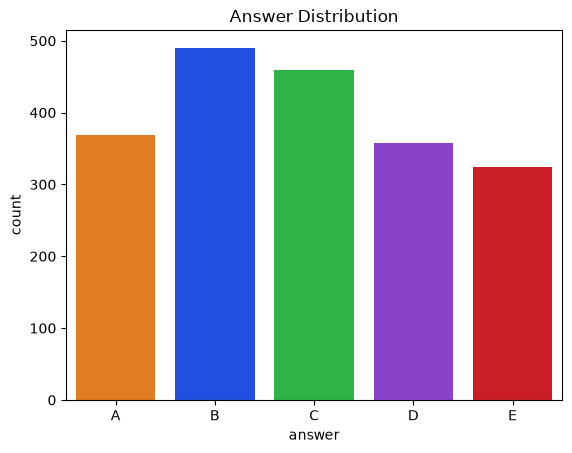

Correct answer distribution:

answer
B    490
C    459
A    369
D    358
E    324
Name: count, dtype: int64

In percentage
answer
B    24.50
C    22.95
A    18.45
D    17.90
E    16.20
Name: proportion, dtype: float64


In [100]:
sns.countplot(
    x="answer",
    data=train_df,
    order=["A","B","C","D","E"],
    hue="answer",
    palette='bright'
)

plt.title("Answer Distribution")
plt.show()

print("Correct answer distribution:\n")

print(train_df["answer"].value_counts())
print("\nIn percentage")
print(train_df["answer"].value_counts(normalize=True)*100)

> Option B and C are mostly the correct answers and option E was the least option when the answer was correct from overall 5 options.
>
> The overall distribution percentage of correct option is 24.5% for option B and 16.2% for option E.

#### Null count

In [101]:
train_df.isnull().sum()

id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
answer    0
dtype: int64

In [102]:
test_df.isnull().sum()

id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
dtype: int64

> There were no null values in the dataset.

### Prompt Length Distribution

In [103]:
train_df["prompt_len"] = (train_df["prompt"].astype(str).str.split().apply(len))

train_df["prompt_len"].describe()

count    2000.00000
mean       18.14650
std         6.78189
min         3.00000
25%        14.00000
50%        17.00000
75%        22.00000
max        51.00000
Name: prompt_len, dtype: float64

> There are 2000 questions in the dataset, with 51 words in the longest prompt/question and 3 words in the smallest prompt. The mean length of prompt is 18 words.

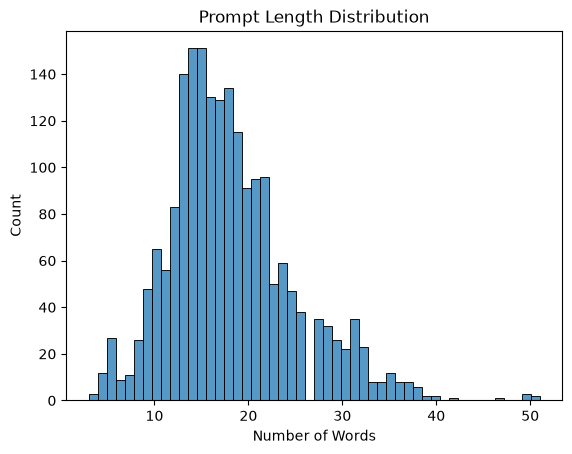

In [104]:
sns.histplot(train_df["prompt_len"], bins=50)

plt.title("Prompt Length Distribution")
plt.xlabel("Number of Words")
plt.show()

### Option Length Distribution

In [105]:
options = ["A", "B", "C", "D", "E"]

for col in options:
    train_df[f"{col}_len"] = train_df[col].astype(str).str.split().str.len()

lengths = train_df[[f"{c}_len" for c in options]]

lengths.describe()

,A_len,B_len,C_len,D_len,E_len
count,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000
mean,26.146000,26.516000,26.54950,25.999500,26.187000
std,17.249651,18.653893,17.20987,17.098909,17.852658
min,1.000000,1.000000,1.00000,1.000000,1.000000
25%,13.000000,12.000000,14.75000,15.000000,13.000000
50%,22.000000,23.000000,24.00000,22.000000,23.000000
75%,37.000000,36.000000,36.00000,36.000000,36.000000
max,81.000000,118.000000,82.00000,78.000000,105.000000


> The max length of the options is 118 words and min length is 1 word out of all the options, and mean length is nearly 26 words in all the options.

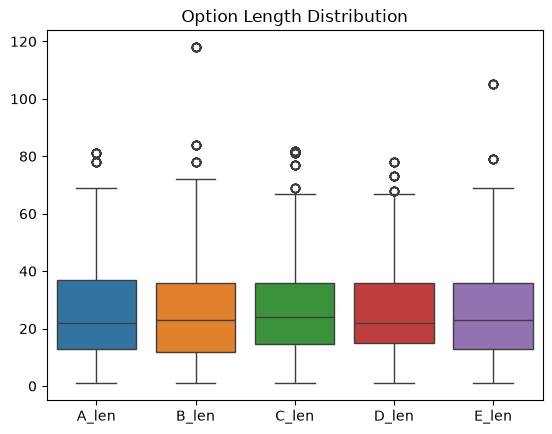

In [106]:
sns.boxplot(data=lengths)

plt.title("Option Length Distribution")
plt.show()

#### Longest Answer Accuracy

In [107]:
options = ["A", "B", "C", "D", "E"]

def get_longest_option(row):
    longest = "A"
    max_len = 0

    for opt in options:
        length = len(str(row[opt]).split())

        if length > max_len:
            max_len = length
            longest = opt

    return longest


train_df["longest_option"] = train_df.apply(get_longest_option, axis=1)

check = (train_df["longest_option"] == train_df["answer"]).mean()

print("Longest Answer Accuracy:", check)

Longest Answer Accuracy: 0.3495


> How often the longest answer is correct: 34.95%.

### Duplicate Check

In [108]:
duplicates = train_df["prompt"].duplicated().sum()

print("Duplicate Questions:", duplicates)

Duplicate Questions: 242


> There are overall 242 duplicate prompts (or questions) in the training dataset.

In [109]:
dup_questions = train_df[train_df["prompt"].duplicated(keep=False)]

dup_questions[ ["prompt","answer"] ].head(50)

,prompt,answer
0,Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and human existence? among the listed options.,B
3,Select the most accurate option: What is Martin Heidegger's view on the relationship between time and human existence? carefully.,B
4,"Identify the correct statement: What is the concept of simultaneity in Einstein's book, Relativity? carefully.",A
5,Identify the correct statement: What is the effect generated by a spinning superconductor? among the listed options.,C
8,Select the most accurate option: What are the constituents of cold dark matter?,A
20,Identify the correct statement: What is the reason that it is nearly impossible to see light emitted at the Lyman-alpha transition wavelength from a star farther than a few hundred light years from Earth? among the listed options.,B
23,Which of the following is correct? Which of the following statements accurately describes the blocking temperature of an antiferromagnetic layer in a spin valve? carefully.,D
27,Identify the correct statement: What is a uniform tiling in the hyperbolic plane? based on the given context.,D
35,Determine the correct option: What is the purpose of the proximity-focusing design in a RICH detector? from the following choices.,D
42,Choose the correct answer: What are permutation-inversion groups? based on the given context.,E


In [110]:
dup_groups = train_df.groupby("prompt")["answer"].nunique()

print((dup_groups > 1).sum())

0


Above value is the prompts that appear with more than one different answer(answer from the column 'answer', not the content in the option)

In [111]:
%pip install spacy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


> Most common terms that were present in the prompt column of the training dataset:

In [112]:
import spacy
from collections import Counter

nlp = spacy.load("en_core_web_lg")

train_entity = Counter()

for text in train_df["prompt"]:

    doc = nlp(str(text))

    for ent in doc.ents:

        train_entity[ent.text] += 1

train_entity.most_common(50)



[('Earth', 44),
 ('two', 38),
 ('three', 34),
 ('first', 32),
 ('Newton', 29),
 ('SI', 23),
 ('Lorentz', 22),
 ('Einstein', 21),
 ("Isaac Newton's", 20),
 ('second', 20),
 ('thylakoid', 20),
 ("Pierre de Fermat's", 16),
 ('Doppler', 16),
 ('Modified Newtonian Dynamics (MOND', 16),
 ('Minkowski', 16),
 ('Maxwell', 16),
 ('Demon', 16),
 ('Liouville', 15),
 ('Kutta', 14),
 ('Peierls', 13),
 ('the Optical Signal', 13),
 ('the Environmental Science Center', 13),
 ('Qatar University', 13),
 ('four', 13),
 ('Evans', 13),
 ('Hamiltonians', 13),
 ('Landau', 13),
 ('Memristor', 12),
 ('the United Nations', 12),
 ('Kapteyn', 12),
 ('Lorenz', 12),
 ('The Essence of Chaos', 12),
 ('Hooke', 12),
 ('1679-1680', 12),
 ('5√100', 12),
 ('Giordano Bruno', 12),
 ('the Lunar Laser Ranging Experiment', 12),
 ('the Deep Space Network', 12),
 ('Moon', 12),
 ("Martin Heidegger's", 11),
 ('Atomristor', 11),
 ('Class L', 11),
 ('the American Petroleum Institute', 11),
 ('API', 11),
 ('Fischer-Tropsch', 11),
 ('8

> Most common terms present in the prompt of the test dataset:

In [113]:
test_df = pd.read_csv('../dataset/test.csv')

test_entity = Counter()

for text in test_df["prompt"]:

    doc = nlp(str(text))

    for ent in doc.ents:

        test_entity[ent.text] += 1

test_entity.most_common(50)

[('Newton', 10),
 ('Earth', 9),
 ('first', 9),
 ('Lorentz', 8),
 ('two', 8),
 ('SI', 6),
 ("Isaac Newton's", 6),
 ('Doppler', 6),
 ('Larmor', 5),
 ('about 100', 5),
 ('Minkowski', 5),
 ('Einstein', 5),
 ('CW', 5),
 ('the James Webb Space Telescope', 4),
 ('Heisenberg', 4),
 ('Carnot', 4),
 ('second', 4),
 ('the American Petroleum Institute', 4),
 ('API', 4),
 ('1660s', 4),
 ('Coordinated Universal Time', 4),
 ('UTC', 4),
 ('Universal Time', 4),
 ('Young', 4),
 ('8.2', 4),
 ('Roche', 4),
 ('three', 4),
 ('Fermi', 4),
 ('Modified Newtonian Dynamics', 4),
 ('Landau', 3),
 ('Evans', 3),
 ('Wigner', 3),
 ('Wilson', 3),
 ('linear', 3),
 ('the Optical Signal', 3),
 ('CYCLOIDEA', 3),
 ('Hooke', 3),
 ('1679-1680', 3),
 ('the Environmental Science Center', 3),
 ('Qatar University', 3),
 ('Peierls', 3),
 ('Kapteyn', 3),
 ('5√100', 3),
 ('Droste', 3),
 ("Pierre de Fermat's", 3),
 ('Erlangen', 3),
 ('Hamiltonians', 2),
 ('four', 2),
 ('Giordano Bruno', 2),
 ('PMF', 2)]

#### Train Test entity overlap check

In [114]:
train_entities = set(train_entity.keys())

test_entities = set(test_entity.keys())

print(len(train_entities))
print(len(test_entities))

print(len(train_entities & test_entities))

97
97
97


In [115]:
sorted(train_entities)

['1660s',
 '1679-1680',
 '5√100',
 '8.2',
 'API',
 'Arthur Eddington',
 'Atomristor',
 'Baryon Acoustic Oscillations',
 'CP',
 'CW',
 'CYCLOIDEA',
 'Carnot',
 'Cauchy',
 'Class L',
 'Coordinated Universal Time',
 'Copernican',
 'Crab',
 'Demon',
 'Doppler',
 'Droste',
 'Earnshaw',
 'Earth',
 'Einstein',
 'Erlangen',
 'Evans',
 'FTIR',
 'Fermi',
 'Fischer-Tropsch',
 'Fresnel',
 'Gauss',
 'Giordano Bruno',
 'Hamiltonian',
 'Hamiltonians',
 'Heisenberg',
 'Hesse',
 'Higgs',
 'Hilbert',
 'Hooke',
 'IL-10',
 "Isaac Newton's",
 'Josephson',
 'Kapteyn',
 'Kutta',
 'Lambda-CDM',
 'Landau',
 'Larmor',
 'Liouville',
 'Lorentz',
 'Lorenz',
 'Lyman',
 "Martin Heidegger's",
 'Maxwell',
 'Memristor',
 'Minkowski',
 'Modified Newtonian Dynamics',
 'Modified Newtonian Dynamics (MOND',
 'Moon',
 'Newton',
 'PDF',
 'PMF',
 'Peierls',
 'Penrose',
 "Pierre de Fermat's",
 'Qatar University',
 'Ramsauer-Townsend',
 'Roche',
 'SI',
 'Schwarzschild',
 'The Essence of Chaos',
 'UTC',
 'Universal Time',
 'Wigne

In [116]:
sorted(test_entities)

['1660s',
 '1679-1680',
 '5√100',
 '8.2',
 'API',
 'Arthur Eddington',
 'Atomristor',
 'Baryon Acoustic Oscillations',
 'CP',
 'CW',
 'CYCLOIDEA',
 'Carnot',
 'Cauchy',
 'Class L',
 'Coordinated Universal Time',
 'Copernican',
 'Crab',
 'Demon',
 'Doppler',
 'Droste',
 'Earnshaw',
 'Earth',
 'Einstein',
 'Erlangen',
 'Evans',
 'FTIR',
 'Fermi',
 'Fischer-Tropsch',
 'Fresnel',
 'Gauss',
 'Giordano Bruno',
 'Hamiltonian',
 'Hamiltonians',
 'Heisenberg',
 'Hesse',
 'Higgs',
 'Hilbert',
 'Hooke',
 'IL-10',
 "Isaac Newton's",
 'Josephson',
 'Kapteyn',
 'Kutta',
 'Lambda-CDM',
 'Landau',
 'Larmor',
 'Liouville',
 'Lorentz',
 'Lorenz',
 'Lyman',
 "Martin Heidegger's",
 'Maxwell',
 'Memristor',
 'Minkowski',
 'Modified Newtonian Dynamics',
 'Modified Newtonian Dynamics (MOND',
 'Moon',
 'Newton',
 'PDF',
 'PMF',
 'Peierls',
 'Penrose',
 "Pierre de Fermat's",
 'Qatar University',
 'Ramsauer-Townsend',
 'Roche',
 'SI',
 'Schwarzschild',
 'The Essence of Chaos',
 'UTC',
 'Universal Time',
 'Wigne

> Both train and test entity looks exactly same

#### Applying tfidf to figure out most important words and phrases

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vec = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1,3),
    max_features=5000
)

X = vec.fit_transform(train_df["prompt"])

scores = X.sum(axis=0).A1
terms = vec.get_feature_names_out()

top_terms = pd.DataFrame({"term": terms, "score": scores}).sort_values("score", ascending=False)

top_terms.head(50)

,term,score
910,correct,69.380362
1984,following,58.725324
3082,option,50.844660
218,answer,50.762138
571,based,38.857752
3355,options,38.564145
2595,listed,38.564145
2596,listed options,38.564145
878,context,37.389011
2184,given,36.903696


> Above are mostly question template terms

#### Semantic similarity check

In [118]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3705.69it/s]


In [119]:
train_emb = model.encode(
    train_df["prompt"].tolist(),
    show_progress_bar=True
)

test_emb = model.encode(
    test_df["prompt"].tolist(),
    show_progress_bar=True
)

Batches: 100%|██████████| 16/16 [00:02<00:00,  7.90it/s]


In [120]:
from sklearn.metrics.pairwise import cosine_similarity

sim = cosine_similarity(
    test_emb,
    train_emb
)

In [121]:
best_sim = sim.max(axis=1)

print(best_sim.mean())
print(best_sim.min())
print(best_sim.max())

0.9864342
0.8853868
1.0000005


>SentenceTransformer embeddings reveal extremely high train-test similarity. The average similarity between test questions and training questions is 0.986.

>Many test questions are either exact copies or minor rephrasings of training questions.

In [127]:
sim = cosine_similarity(test_emb, train_emb)

for i in range(10):

    idx = np.argmax(sim[i])

    print("="*100)
    print("TEST")
    print(test_df.iloc[i]["prompt"])

    print("\nTRAIN")
    print(train_df.iloc[idx]["prompt"])

    print("\nSIM")
    print(sim[i][idx])

TEST
Pick the best possible answer: What is the relationship between the Hamiltonians and eigenstates in supersymmetric quantum mechanics? carefully.

TRAIN
Pick the best possible answer: What is the relationship between the Hamiltonians and eigenstates in supersymmetric quantum mechanics? carefully.

SIM
1.0000001
TEST
What is the estimated redshift of CEERS-93316, a candidate high-redshift galaxy observed by the James Webb Space Telescope?

TRAIN
What is the estimated redshift of CEERS-93316, a candidate high-redshift galaxy observed by the James Webb Space Telescope?

SIM
1.0
TEST
Pick the best possible answer: What is the reason for the sun appearing slightly yellowish when viewed from Earth? from the following choices.

TRAIN
Select the most accurate option: What is the reason for the sun appearing slightly yellowish when viewed from Earth? from the following choices.

SIM
0.964543
TEST
What is the significance of the redshift-distance relationship in determining the expansion his

In [123]:
train_prompts = set(train_df["prompt"])

test_prompts = set(test_df["prompt"])

common = train_prompts & test_prompts

print("Common prompts:", len(common))
print("Train prompts:", len(train_prompts))
print("Test prompts:", len(test_prompts))

Common prompts: 267
Train prompts: 1758
Test prompts: 492


>(267/1758) 15% of unique train questions reappear in test.

>(267/492) 54% of the test questions are exactly the same as questions in the training data.


In [ ]:
common_prompts = set(train_df["prompt"]) & set(test_df["prompt"])

for prompt in list(common_prompts)[:5]:

    print("=" * 100)
    print(prompt)

    train_row = train_df[train_df["prompt"] == prompt].iloc[0]

    print("\nTRAIN OPTIONS")
    for option in ["A", "B", "C", "D", "E"]:
        print(option, train_row[option])

    test_row = test_df[test_df["prompt"] == prompt].iloc[0]

    print("\nTEST OPTIONS")
    for option in ["A", "B", "C", "D", "E"]:
        print(option, test_row[option])

What are the two main factors that cause resistance in a metal?

TRAIN OPTIONS
A The amount of resistance in a metal is mainly caused by the temperature and the pressure applied to the metal. Higher temperatures cause bigger vibrations, and pressure causes the metal to become more compact, leading to more resistance.
B The amount of resistance in a metal is mainly caused by the temperature and the purity of the metal. Higher temperatures cause bigger vibrations, and a mixture of different ions acts as an irregularity.
C The amount of resistance in a metal is mainly caused by the temperature and the thickness of the metal. Higher temperatures cause bigger vibrations, and thicker metals have more irregularities, leading to more resistance.
D The amount of resistance in a metal is mainly caused by the purity of the metal and the amount of pressure applied to the metal. A mixture of different ions acts as an irregularity, and pressure causes the metal to become more compact, leading to mor

In [125]:
common_prompts = (set(train_df["prompt"]) & set(test_df["prompt"]))

exact_option_matches = 0

for prompt in common_prompts:

    train_row = train_df[train_df["prompt"] == prompt].iloc[0]

    test_row = test_df[test_df["prompt"] == prompt].iloc[0]

    same = True

    for col in ["A","B","C","D","E"]:
        if str(train_row[col]).strip() != str(test_row[col]).strip():
            same = False
            break

    if same:
        exact_option_matches += 1

print(exact_option_matches)
print(exact_option_matches / len(common_prompts))

255
0.9550561797752809


Out of the 267 questions that appear in both the training and test sets, 255 (95.5%) have exactly the same answer choices.

This means that 255 out of 492 test questions (51.8%) are exact copies of questions already seen during training, including their answer options.